In [1]:
import sys
sys.path.append("..")

In [2]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [3]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from presto import Presto

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r"\usepackage{amssymb}\usepackage{amsmath}\usepackage{times}"

### Load data and results

In [7]:
paper_figure_path = "../../ICML2024_EmbedEQ/images"

In [8]:
config = OmegaConf.load("../config.yml")

In [9]:
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}

In [10]:
with open("../data/combined_results.pkl", "rb") as f:
    results = pickle.load(f)

In [11]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)

### Average landscapes for varying numbers of projections

In [12]:
def get_short_name(dataset):
    if "patent" in dataset:
        return "patents"
    elif "arxiv" in dataset:
        return "arxiv"
    elif "cnn" in dataset:
        return "cnn"
    elif "xsum" in dataset:
        return "bbc"
    else:
        raise NotImplementedError(dataset)

def get_long_name(dataset):
    if dataset == "patents":
        return 'big_patent a'
    elif dataset == "arxiv":
        return 'gfissore/arxiv-abstracts-2021'
    elif dataset == "cnn":
        return 'cnn_dailymail 3.0.0'
    elif dataset == "bbc":
        return 'EdinburghNLP/xsum'
    else:
        raise NotImplementedError(dataset)
    
    
def create_score_df(scores):
    df = pd.DataFrame(scores).T.sort_values(0, ascending=False).reset_index().rename(
        {"level_0":"m1", "level_1":"m2", 0:"dim0", 1:"dim1", 2:"dim2"}, axis=1)
    df["m1_dataset"] = df.m1.map(lambda x:get_short_name(x[0]))
    df["m2_dataset"] = df.m2.map(lambda x:get_short_name(x[0]))
    df["datasets"] = df.m1_dataset + "/" + df.m2_dataset
    df["m1_model"] = df.m1.map(lambda x:x[1])
    df["m2_model"] = df.m2.map(lambda x:x[1])
    df["models"] = df.m1_model + "/" + df.m2_model
    df["m1_n_samples"] = df.m1.map(lambda x:x[2])
    df["m2_n_samples"] = df.m2.map(lambda x:x[2])
    df["sample_diff"] = [abs(x-y) for x,y in zip(df.m1_n_samples, df.m2_n_samples)]
    if df.m1.map(len)[0] == 4:
        df["m1_n_projections"] = df.m1.map(lambda x:x[3])
        df["m2_n_projections"] = df.m2.map(lambda x:x[3])
        df["projection_diff"] = [abs(x-y) for x,y in zip(df.m1_n_projections, df.m2_n_projections)]
    df["aggregate_presto"] = df.dim0 + df.dim1 + df.dim2
    df["average_presto"] = df["aggregate_presto"] / 3
    return df

In [13]:
avg_landscapes = dict()
finegrained = dict()
finegrained_scores = dict()
for dataset, v1 in results.items():
    for model, v2 in v1.items():
        for n_samples, v3 in v2.items():
            avg_landscapes[(dataset, model, n_samples)] = metric.average_landscape(v3["landscapes"])
            for n_projections in config.n_projections:
                finegrained[(dataset, model, n_samples, n_projections)] = metric.average_landscape({i:v3["landscapes"][i][:n_projections] for i in range(config.max_homology_dim + 1)})
for (k1,v1), (k2,v2) in list(combinations(finegrained.items(),2)) + [((k1,v1),(k1,v1)) for k1, v1 in finegrained.items()]:
    finegrained_scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

In [14]:
df_fine = create_score_df(finegrained_scores)
print(df_fine.shape)
df_fine.head(2)

(205120, 19)


,m1,m2,dim0,dim1,dim2,m1_dataset,m2_dataset,datasets,m1_model,m2_model,models,m1_n_samples,m2_n_samples,sample_diff,m1_n_projections,m2_n_projections,projection_diff,aggregate_presto,average_presto
0,"(gfissore/arxiv-abstracts-2021, all-distilrobe...","(EdinburghNLP/xsum, all-distilroberta-v1, 1024...",0.679083,0.080847,0.032655,arxiv,bbc,arxiv/bbc,all-distilroberta-v1,all-distilroberta-v1,all-distilroberta-v1/all-distilroberta-v1,16384,1024,15360,4,4,0,0.792586,0.264195
1,"(gfissore/arxiv-abstracts-2021, all-distilrobe...","(EdinburghNLP/xsum, all-distilroberta-v1, 1024...",0.657864,0.067605,0.028935,arxiv,bbc,arxiv/bbc,all-distilroberta-v1,all-distilroberta-v1,all-distilroberta-v1/all-distilroberta-v1,16384,1024,15360,8,4,4,0.754404,0.251468


In [15]:
df_fine.to_csv("finegrained_score_data.csv.gz")

### Same model, same dataset – looking at effect of sample size and number of projections

In [16]:
sorted_models = ['all-mpnet-base-v2','all-MiniLM-L6-v2', 'all-distilroberta-v1','multi-qa-distilbert-cos-v1']
sorted_datasets = ['arxiv', 'bbc', 'cnn', 'patents']

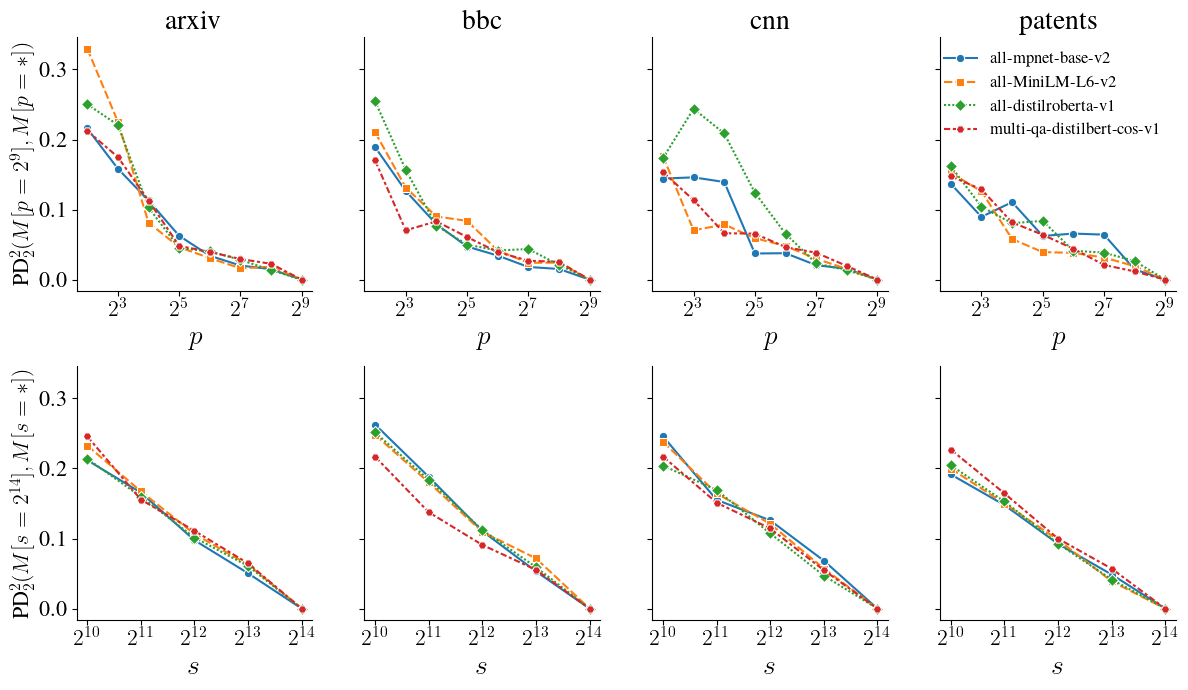

In [17]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 16
legend_fontsize = 12
title_fontsize = 20
df = df_fine.query("m1_model == m2_model and m1_dataset == m2_dataset and m2_n_samples == @samples_m2 and m2_n_projections == @projections_m2"
                  ).sort_values("m1_model", key=lambda vec:vec.map(lambda x:sorted_models.index(x)))
fig, ax = plt.subplots(2,len(datasets),figsize=(3 * len(datasets),3.5 * 2), sharey=True, sharex=False)
for idx,dataset in enumerate(sorted_datasets):
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_samples == m2_n_samples"), 
                 x="m1_n_projections", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[0][idx],
                 markers="osDH",
                 legend=False if idx != len(datasets) - 1 else True
                )
    ax[0][idx].set_title(dataset.split("/")[-1], fontsize=title_fontsize)
    ax[0][idx].set_ylabel(r"PD"+"$^2_2(M[p = 2^{9}],M[p = *])$", fontsize=label_fontsize)
    ax[0][idx].set_xlabel(rf"$p$", fontsize=title_fontsize)
    ax[0][idx].set_xscale("log", base=2)
    
    sns.lineplot(data=df.query("m1_dataset == @dataset and m1_n_projections == m2_n_projections"), 
                 x="m1_n_samples", 
                 y="aggregate_presto", 
                 hue="m1_model",
                 style="m1_model",
                 ax=ax[1][idx],
                 markers="osDH", legend=False
                )
    ax[1][idx].set_ylabel(r"PD"+"$^2_2(M[s = 2^{14}],M[s = *])$", fontsize=label_fontsize)
    ax[1][idx].set_xlabel(rf"$s$", fontsize=title_fontsize)
    ax[1][idx].set_xscale("log", base=2)
ax[0][-1].legend(title="",frameon=False, fontsize=legend_fontsize)
ax[0][0].set_yticks(np.arange(0,0.31,0.1))
for axx in ax[0]:
    axx.set_xticks([2**x for x in range(3,10,2)])
    axx.set_xticklabels([rf"$2^{x}$" for x in range(3,10,2)], fontsize=label_fontsize)
for axx in ax[1]:
    axx.set_xticks([2**x for x in range(10,15,1)])
    axx.set_xticklabels([r"$2^{"+str(x)+r"}$" for x in range(10,15,1)], fontsize=label_fontsize)
for axx in [ax[0][0],ax[1][0]]:
    axx.set_yticklabels([round(x,1) for x in np.arange(0,0.31,0.1)], fontsize=label_fontsize)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/effects_sample-size_n-projections.pdf", bbox_inches="tight", transparent=True)

### Different model, same dataset, same sample size, same number of projections

In [18]:
samples_m2 = 16384
projections_m2 = 512
label_fontsize = 14
legend_fontsize = 12
df = df_fine.query("m1_dataset == m2_dataset and m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2")

In [19]:
pdfs = dict()
for dataset in df.m1_dataset.unique():
    pdf = df.query("m1_dataset == @dataset").pivot(index=["m1_model"], columns=["m2_model"], values="aggregate_presto"
                                                  ).sort_index(key=lambda v:v.map(lambda x:x.lower()), ascending=False)
    pdf = pdf[sorted(pdf.columns, key=lambda x:x.lower())]
    pdfs[dataset] = pdf.loc[[*pdf.index[1:], pdf.index[0]]][[pdf.columns[-1],*pdf.columns[:-1]]].fillna(0)
    pdfs[dataset] += pdfs[dataset].T

In [20]:
melted_df = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2"
             ).melt(id_vars=["m1_dataset", "m2_dataset", "m1_model", "m2_model"], value_vars="aggregate_presto", 
                    value_name="score").pivot(index=["m1_dataset","m1_model"], columns=["m2_dataset","m2_model"], values=["score"])

In [21]:
melted_df.columns = melted_df.columns.droplevel()

In [22]:
for idx1 in melted_df.index:
    for idx2 in melted_df.columns:
        if pd.isna(melted_df.at[idx1,idx2]) and idx2 in melted_df.columns and idx1 in melted_df.index:
            melted_df.at[idx1,idx2] = melted_df.at[idx2,idx1]

In [23]:
melted_df = melted_df.sort_index()[sorted(melted_df.columns)]

In [24]:
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

In [25]:
method = "ward"
metric_ = "euclidean"

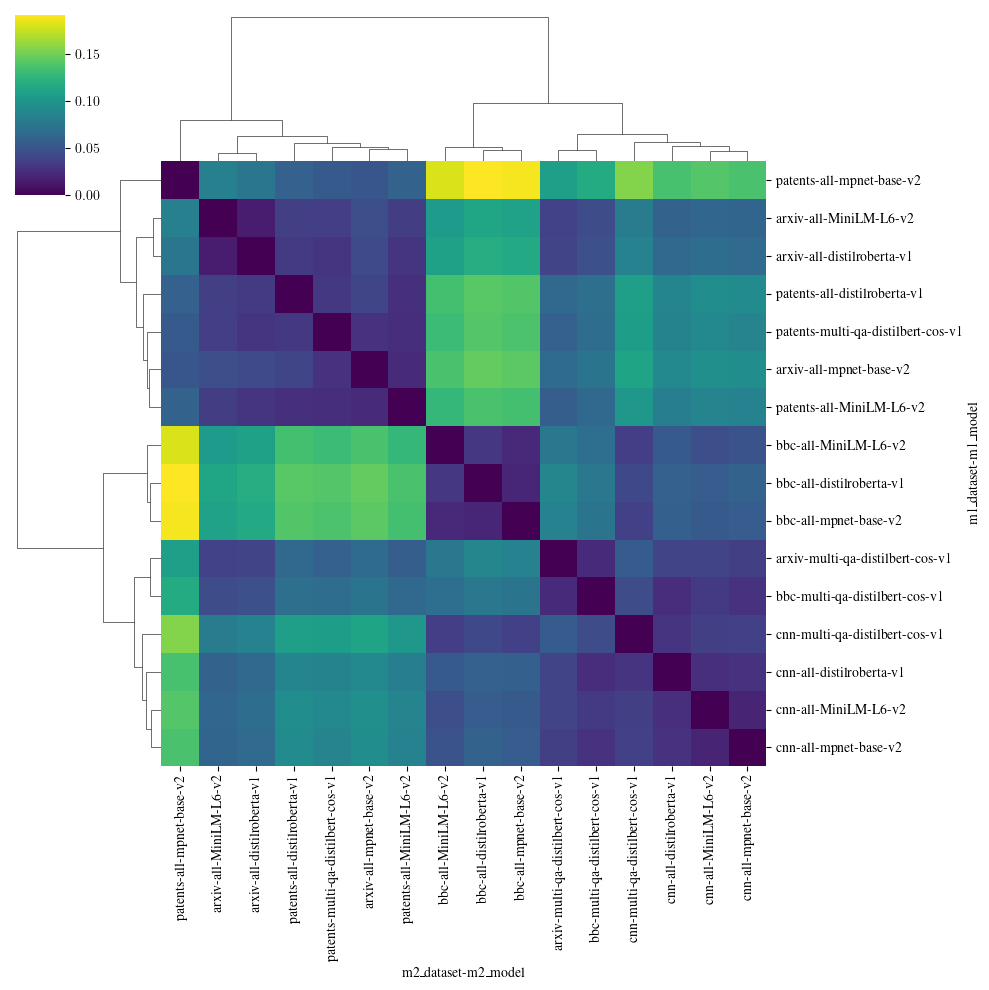

In [26]:
linkage = hc.linkage(sp.distance.squareform(melted_df), method=method, metric=metric_)
sns.clustermap(melted_df, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
plt.savefig(f"{paper_figure_path}/effects_dataset_model_clustermap_method-{method}_metric-{metric_}.pdf", bbox_inches="tight", transparent=True)

In [27]:
method = "ward"
metric = "euclidean"
for idx,dataset in enumerate(sorted_datasets):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_dataset == m2_dataset == @dataset"
                 ).pivot(index="m1_model", columns="m2_model", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"{paper_figure_path}/effects_model-only_dataset-{dataset}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

In [28]:
method = "ward"
metric = "euclidean"
for idx,model in enumerate(sorted_models):
    melted_small = df_fine.query("m1_n_samples == m2_n_samples == @samples_m2 and m1_n_projections == m2_n_projections == @projections_m2 "
                  + "and m1_model == m2_model == @model"
                 ).pivot(index="m1_dataset", columns="m2_dataset", values="aggregate_presto").sort_index().fillna(0)
    melted_small += melted_small.T
    linkage = hc.linkage(sp.distance.squareform(melted_small), method=method, metric=metric)
    sns.clustermap(melted_small, row_linkage=linkage, col_linkage=linkage, cmap="viridis")
    plt.savefig(f"{paper_figure_path}/effects_data-only_model-{model}_clustermap_method-{method}_metric-{metric}.pdf", bbox_inches="tight", transparent=True)
    plt.close()

### Model comparisons with varying number of projections (bands are different sample sizes)

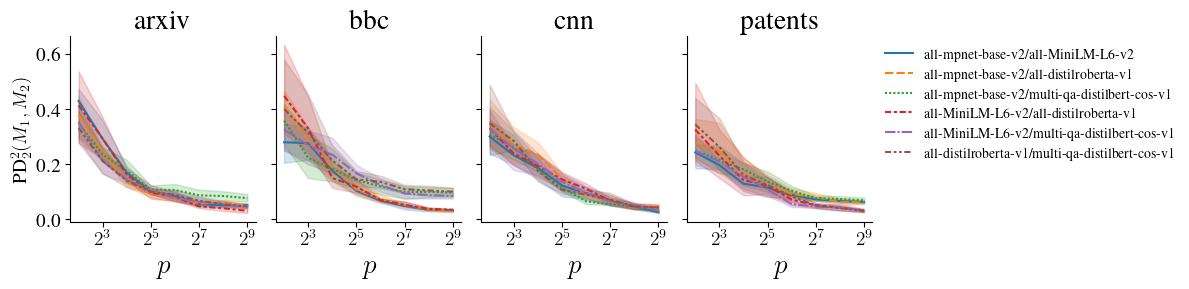

In [29]:
sorted_model_pairs = [
       'all-mpnet-base-v2/all-MiniLM-L6-v2',
       'all-mpnet-base-v2/all-distilroberta-v1',
       'all-mpnet-base-v2/multi-qa-distilbert-cos-v1',
        'all-MiniLM-L6-v2/all-distilroberta-v1',
       'all-MiniLM-L6-v2/multi-qa-distilbert-cos-v1',
                'all-distilroberta-v1/multi-qa-distilbert-cos-v1',]
df = df_fine.query("m1_n_samples == m2_n_samples and m1_n_projections == m2_n_projections "
                  + "and m1_dataset == m2_dataset and m1_model != m2_model"
                 )
fig, ax = plt.subplots(1,len(datasets),figsize=(3 * len(datasets),3), sharex=True, sharey=True)
for idx,dataset in enumerate(sorted_datasets):
    sns.lineplot(data=df.query("m1_dataset == @dataset").sort_values("models", key=lambda vec:vec.map(lambda x:sorted_model_pairs.index(x))), 
                        y="aggregate_presto", x="m1_n_projections", ax=ax[idx], hue="models", legend=False if idx != len(datasets)-1 else True,
                style="models"
                )
    ax[idx].set_title(dataset, fontsize=title_fontsize)
    ax[idx].set_xscale("log", base=2)
    ax[idx].set_xlabel("$p$", fontsize=title_fontsize)
for axx in ax:
    axx.set_yticks(np.arange(0.0,0.7,0.2))
    axx.set_yticklabels([round(x,2) for x in np.arange(0.0,0.7,0.2)], fontsize=label_fontsize)
    axx.set_xticks([2**x for x in range(3,10,2)])
    axx.set_xticklabels([r"$2^"+str(x)+"$" for x in range(3,10,2)], fontsize=label_fontsize)
ax[0].set_ylabel(r"PD"+"$^2_2(M_1,M_2)$", fontsize=label_fontsize)
ax[-1].legend(title="", bbox_to_anchor=(1,1), frameon=False)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/effects_n-projections_model-comparisons.pdf", bbox_inches="tight", transparent=True)

### Exploring Landscape Norms

In [30]:
all_norms = dict()
for idx, dataset in enumerate(datasets):
    for idx2,model in enumerate(models):
        for n_samples in config.n_samples:
            landscapes = results[dataset][model][n_samples]["landscapes"]
            landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
            all_norms[dataset,model,n_samples] = landscape_norms_agg[:]

In [31]:
all_norms_df = pd.DataFrame(all_norms)
all_norms_df = pd.DataFrame(all_norms_df.unstack()).reset_index(
).rename({"level_0":"dataset", "level_1":"model", "level_2": "n_samples", "level_3": "projection", 0:"score"}, axis=1)
all_norms_df["config"] = all_norms_df.dataset + "/" + all_norms_df.model
all_norms_df["dataset"] = all_norms_df.dataset.map(lambda dataset:get_short_name(dataset))
all_norms_df.head()

,dataset,model,n_samples,projection,score,config
0,patents,all-mpnet-base-v2,1024,0,0.895625,big_patent a/all-mpnet-base-v2
1,patents,all-mpnet-base-v2,1024,1,0.983234,big_patent a/all-mpnet-base-v2
2,patents,all-mpnet-base-v2,1024,2,1.132316,big_patent a/all-mpnet-base-v2
3,patents,all-mpnet-base-v2,1024,3,1.212579,big_patent a/all-mpnet-base-v2
4,patents,all-mpnet-base-v2,1024,4,0.960146,big_patent a/all-mpnet-base-v2


In [79]:
all_norms_df.query("model == @model and dataset == @dataset").groupby("n_samples").agg(dict(score="mean"))

,score
n_samples,
1024,1.162536
2048,1.115305
4096,1.043104
8192,0.985879
16384,0.939298


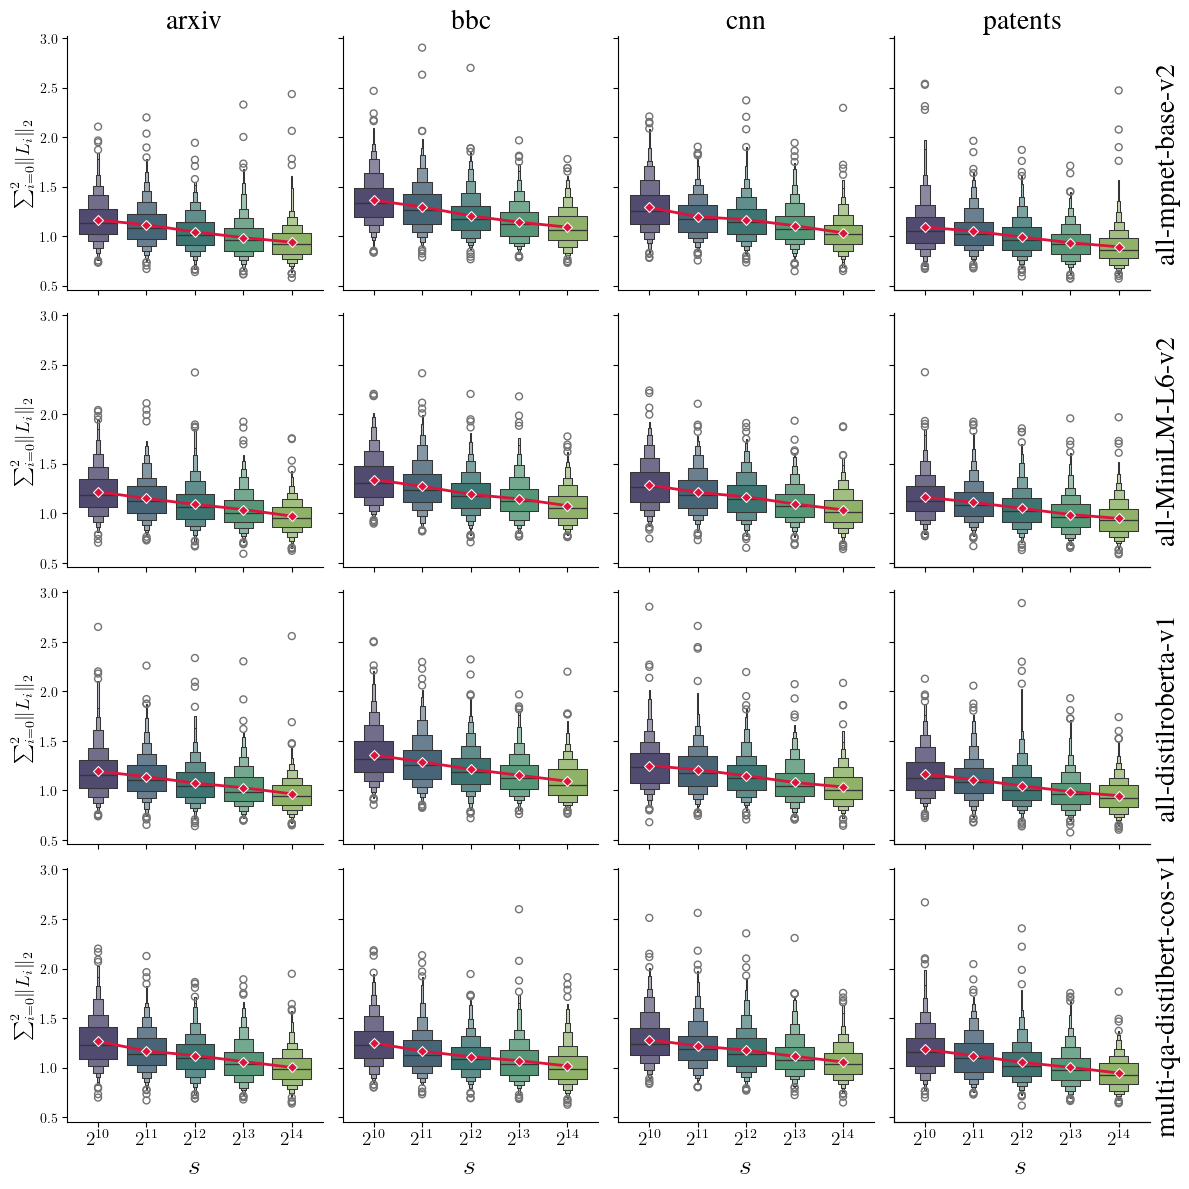

In [96]:
fig, ax = plt.subplots(len(datasets),len(models), figsize=(len(models) * 3, len(datasets) * 3), sharey=True, sharex=True)
for idx, model in enumerate(sorted_models):
    for idx2,dataset in enumerate(sorted_datasets):
        sns.boxenplot(data=all_norms_df.query("model == @model and dataset == @dataset"), x="n_samples", y="score", ax=ax[idx][idx2], palette="viridis",
                      saturation=0.5,
                      legend=False if idx != 3 else True)
        sns.lineplot(x=[0,1,2,3,4], y=all_norms_df.query("model == @model and dataset == @dataset").groupby("n_samples").agg(dict(score="mean")).score, 
                     ax=ax[idx][idx2], marker="D", markersize=5, lw=2, color="crimson")
        ax[0][idx2].set_title(dataset, fontsize=title_fontsize)
    twinx = ax[idx][-1].twinx()
    twinx.set_yticks([])
    twinx.set_ylabel(model, fontsize=title_fontsize)
for axx in ax.ravel():
    axx.set_ylabel(r"$\sum_{i=0}^2\lVert L_i \rVert_2$", fontsize=label_fontsize)
    axx.set_xticklabels([r"$2^{"+str(x)+"}$" for x in range(10,15)],fontsize=label_fontsize)
    axx.set_xlabel("$s$", fontsize=title_fontsize)
sns.despine(fig)
plt.tight_layout()
#plt.savefig(f"{paper_figure_path}/boxen_landscape-norms.pdf", bbox_inches="tight", transparent=True)

### Some normality testing and stats on landscape-norm distributions

In [67]:
from scipy.stats import shapiro, pearsonr, kendalltau, spearmanr

In [57]:
n_hypothesis_tests = all_norms_df.n_samples.nunique() * all_norms_df.dataset.nunique() * all_norms_df.model.nunique()

In [63]:
for n_samples in all_norms_df.n_samples.unique():
    for dataset in all_norms_df.dataset.unique():
        for model in all_norms_df.model.unique():
            relevant = all_norms_df.query("n_samples == @n_samples and dataset == @dataset and model == @model")
            mean, std = relevant.score.mean(), relevant.score.std()
            shap =  shapiro(relevant.score)
            print(n_samples, dataset, model, round(mean,2), round(std,2), shap.pvalue * n_hypothesis_tests)
        print("===")
    print()

1024 patents all-mpnet-base-v2 1.09 0.25 8.051439523479439e-18
1024 patents all-MiniLM-L6-v2 1.16 0.22 1.595044625893327e-11
1024 patents all-distilroberta-v1 1.16 0.23 2.3423509659670216e-10
1024 patents multi-qa-distilbert-cos-v1 1.18 0.24 5.463047006958044e-12
===
1024 arxiv all-mpnet-base-v2 1.16 0.21 7.742422258871784e-09
1024 arxiv all-MiniLM-L6-v2 1.22 0.23 2.2693772194770645e-07
1024 arxiv all-distilroberta-v1 1.19 0.25 4.426189978228544e-13
1024 arxiv multi-qa-distilbert-cos-v1 1.26 0.25 1.2702464635694355e-08
===
1024 cnn all-mpnet-base-v2 1.29 0.24 1.8638253607150546e-07
1024 cnn all-MiniLM-L6-v2 1.29 0.24 6.26053378027791e-07
1024 cnn all-distilroberta-v1 1.25 0.24 6.822920185648243e-13
1024 cnn multi-qa-distilbert-cos-v1 1.28 0.24 1.5930507780981262e-11
===
1024 bbc all-mpnet-base-v2 1.36 0.24 1.2662757065129426e-07
1024 bbc all-MiniLM-L6-v2 1.34 0.24 6.2292787594842025e-09
1024 bbc all-distilroberta-v1 1.36 0.26 4.607025264752318e-11
1024 bbc multi-qa-distilbert-cos-v1 1.

In [41]:
all_norms_df.query("n_samples == 16384 and dataset == 'patents' and model == 'all-mpnet-base-v2'")

,dataset,model,n_samples,projection,score,config
2048,patents,all-mpnet-base-v2,16384,0,0.650818,big_patent a/all-mpnet-base-v2
2049,patents,all-mpnet-base-v2,16384,1,0.833899,big_patent a/all-mpnet-base-v2
2050,patents,all-mpnet-base-v2,16384,2,0.993207,big_patent a/all-mpnet-base-v2
2051,patents,all-mpnet-base-v2,16384,3,0.851082,big_patent a/all-mpnet-base-v2
2052,patents,all-mpnet-base-v2,16384,4,0.690743,big_patent a/all-mpnet-base-v2
...,...,...,...,...,...,...
2555,patents,all-mpnet-base-v2,16384,507,0.837310,big_patent a/all-mpnet-base-v2
2556,patents,all-mpnet-base-v2,16384,508,0.807102,big_patent a/all-mpnet-base-v2
2557,patents,all-mpnet-base-v2,16384,509,0.705103,big_patent a/all-mpnet-base-v2
2558,patents,all-mpnet-base-v2,16384,510,0.903404,big_patent a/all-mpnet-base-v2


In [71]:
pearsonr(all_norms_df.n_samples, all_norms_df.score, alternative="less"
        ), kendalltau(all_norms_df.n_samples, all_norms_df.score, alternative="less"
                     ), spearmanr(all_norms_df.n_samples, all_norms_df.score, alternative="less")

(PearsonRResult(statistic=-0.3339423046779076, pvalue=0.0),
 SignificanceResult(statistic=-0.2785190914345957, pvalue=0.0),
 SignificanceResult(statistic=-0.3757993237874577, pvalue=0.0))

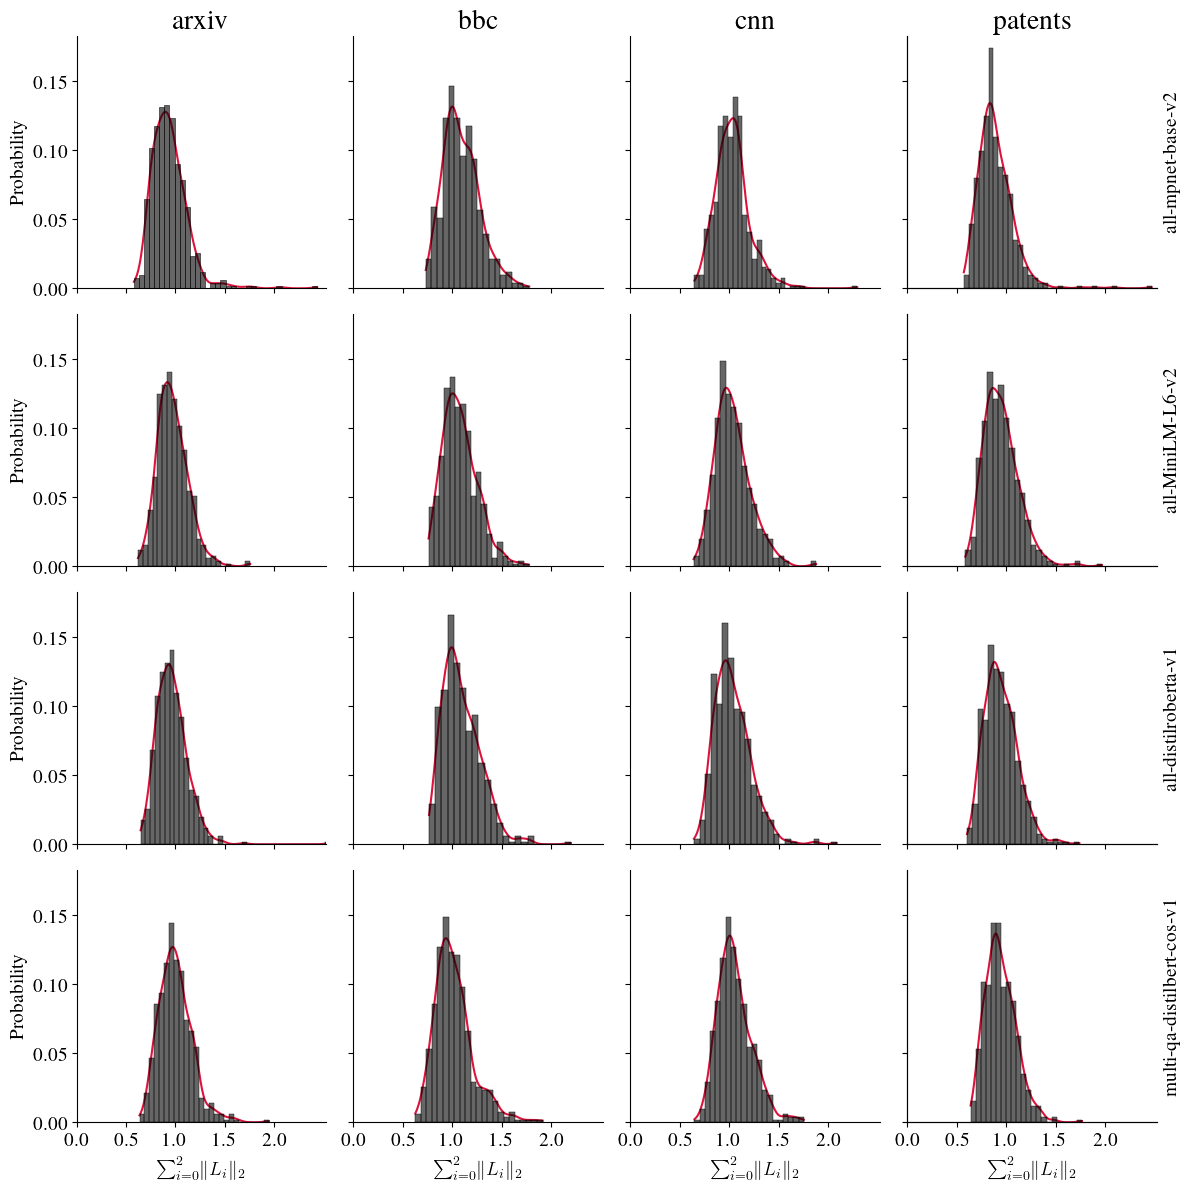

In [33]:
fig, ax = plt.subplots(len(datasets),len(models), figsize=(len(models) * 3, len(datasets) * 3), sharey=True, sharex=True)
for idx, model in enumerate(sorted_models):
    for idx2,dataset in enumerate(sorted_datasets):
        landscapes = results[get_long_name(dataset)][model][16384]["landscapes"]
        landscape_norms_agg = [sum(np.linalg.norm(x) for x in [landscapes[0][idx], landscapes[1][idx], landscapes[2][idx]]) for idx in range(len(landscapes[0]))]
        sns.histplot(landscape_norms_agg, ax=ax[idx][idx2], stat="probability", kde=True, color="k", alpha=0.6)
        ax[idx][idx2].lines[0].set_color('crimson')
        ax[idx][idx2].lines[0].set_zorder(-1)
        ax[idx][idx2].set_xlim(0,ax[idx][idx2].get_xlim()[-1])
        ax[idx][idx2].set_xlabel(r"$\sum_{i=0}^2\lVert L_i \rVert_2$", fontsize=label_fontsize)
        ax[idx][idx2].set_ylabel("Probability", fontsize=label_fontsize)
        ax[0][idx2].set_title(dataset, fontsize=title_fontsize)
        xticks = [0,0.5,1,1.5,2]
        ax[idx][idx2].set_xticks(xticks)
        ax[idx][idx2].set_xticklabels([f"{x:.1f}" for x in xticks], fontsize=label_fontsize)
        yticks = [0.00, 0.05, 0.10, 0.15]
        ax[idx][idx2].set_yticks(yticks)
        ax[idx][idx2].set_yticklabels([f"{x:.2f}" for x in yticks], fontsize=label_fontsize)
    axx = ax[idx][-1].twinx()
    axx.set_ylabel(model, fontsize=label_fontsize)
    axx.set_yticks([])
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/distributions_landscape-norms.pdf", bbox_inches="tight", transparent=True)

### Subsampling

In [403]:
rng = np.random.default_rng(42)
n_projections = 512
n_subsamples = 2**7
subsample_size = 512
subsampled_avgs = dict()

metric = Presto(max_homology_dim=config.max_homology_dim, n_components=config.n_components, normalize=config.normalize)
for dataset, v1 in results.items():
    for model, v2 in v1.items():
        print(dataset, model)
        for v3 in [v2[16384]]:
            for i in range(n_subsamples):
                subsampled_avgs[(dataset, model, i)] = metric.average_landscape({i:rng.choice(v3["landscapes"][i],subsample_size,replace=False) for i in range(config.max_homology_dim + 1)})

big_patent a all-mpnet-base-v2
big_patent a all-MiniLM-L6-v2
big_patent a all-distilroberta-v1
big_patent a multi-qa-distilbert-cos-v1
gfissore/arxiv-abstracts-2021 all-mpnet-base-v2
gfissore/arxiv-abstracts-2021 all-MiniLM-L6-v2
gfissore/arxiv-abstracts-2021 all-distilroberta-v1
gfissore/arxiv-abstracts-2021 multi-qa-distilbert-cos-v1
cnn_dailymail 3.0.0 all-mpnet-base-v2
cnn_dailymail 3.0.0 all-MiniLM-L6-v2
cnn_dailymail 3.0.0 all-distilroberta-v1
cnn_dailymail 3.0.0 multi-qa-distilbert-cos-v1
EdinburghNLP/xsum all-mpnet-base-v2
EdinburghNLP/xsum all-MiniLM-L6-v2
EdinburghNLP/xsum all-distilroberta-v1
EdinburghNLP/xsum multi-qa-distilbert-cos-v1


In [404]:
from itertools import product

In [405]:
tuples = list(product(datasets, models))

In [406]:
subsampled_scores = dict()
for tuple in tuples:
    for i,j in combinations(list(range(n_subsamples)),2):
        subsampled_scores[(*tuple,i,j)] = metric.compute_presto_scores(subsampled_avgs[(*tuple,i)], subsampled_avgs[(*tuple,j)])

In [407]:
subsampled_df = pd.DataFrame(pd.DataFrame(subsampled_scores).unstack()).reset_index(
    
).rename({"level_0":"dataset", "level_1":"model", "level_2":"i", "level_3":"j", "level_4":"dim", 0:"score"}, axis=1)
subsampled_df["dataset"] = subsampled_df.dataset.map(get_short_name)

In [408]:
subsampled_df_agg = subsampled_df.groupby(["dataset","model","i","j"]).agg(dict(score=sum))

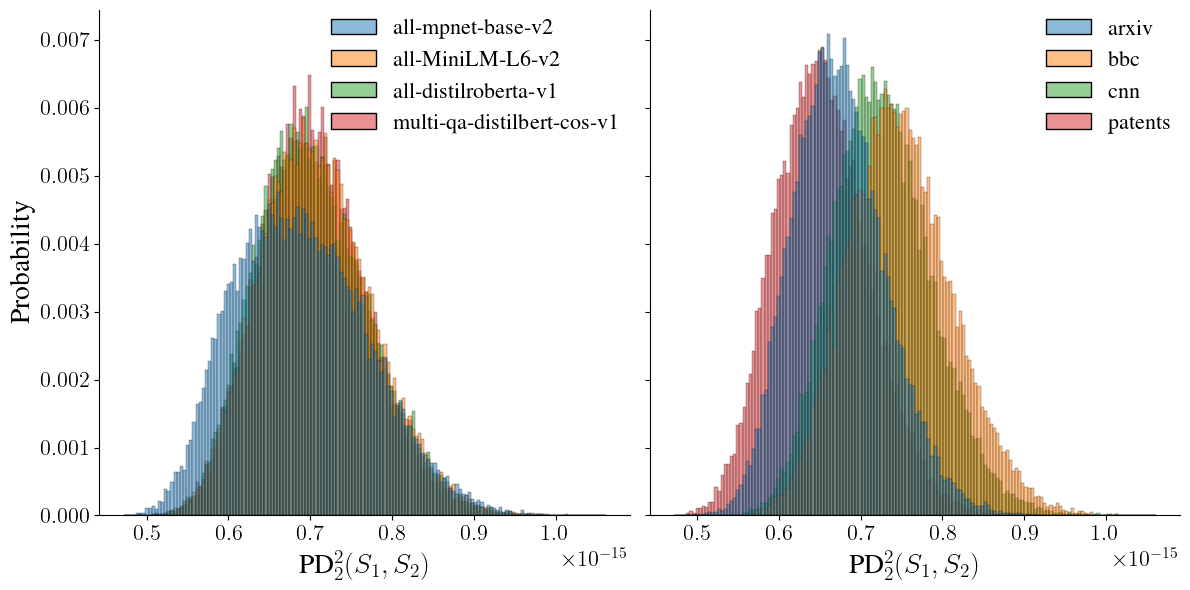

In [455]:
fig, ax = plt.subplots(1,2,figsize=(12,6), sharey=True, sharex=True)
for idx,elem in enumerate(["model", "dataset"]):
    sns.histplot(subsampled_df_agg.sort_values(elem, key=lambda vec:vec.map(lambda x:sorted_models.index(x)) if elem == "model" else vec.map(lambda x:sorted_datasets.index(x))), 
                                               x="score", stat="probability", hue=elem, ax=ax[idx], 
                 legend=True)
    leg1 = ax[idx].get_legend()
    h1 = leg1.legend_handles
    leg1.remove()
    ax[idx].legend(h1, sorted_datasets if elem == "dataset" else sorted_models, frameon=False, fontsize=label_fontsize, loc="upper right", borderaxespad=0)
    ax[idx].set_xlabel(r"PD"+"$^2_2(S_1,S_2)$", fontsize=title_fontsize)
    ax[idx].set_ylabel("Probability", fontsize=title_fontsize)
    offset_text = ax[idx].xaxis.get_offset_text()
    offset_text.set_fontsize(label_fontsize)
    xtls = ax[idx].get_xticklabels()
    for l in xtls:
        l.set_fontsize(label_fontsize)
ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=label_fontsize)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/subsampling_presto_nosep.pdf", bbox_inches="tight", transparent=True)

In [417]:
subsampled_df_agg.head()

score
dataset model            i j              
arxiv   all-MiniLM-L6-v2 0 1  6.209676e-16
                           2  7.417066e-16
                           3  6.997383e-16
                           4  7.305490e-16
                           5  7.609097e-16

In [442]:
from matplotlib import cm

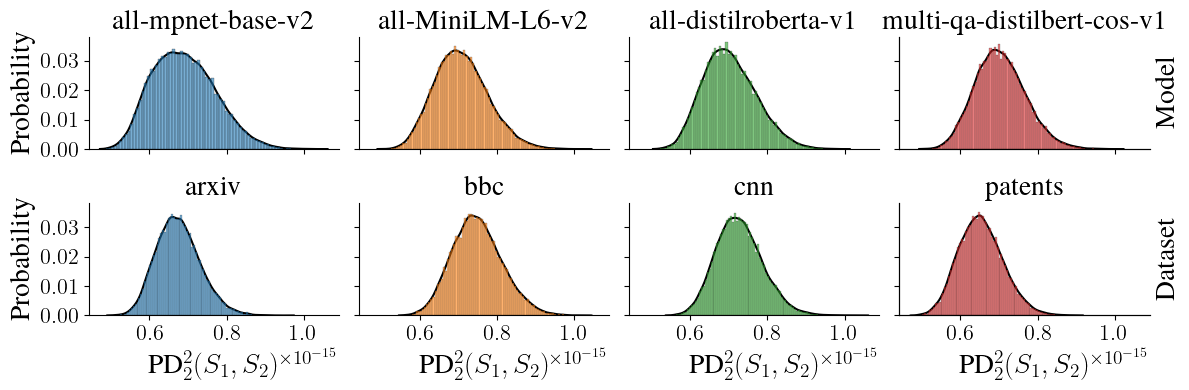

In [456]:
cmap = cm.tab10(np.linspace(0,1,11))
fig, ax = plt.subplots(2,4,figsize=(12,4), sharey=True, sharex=True)
for idx,elem in enumerate(["model", "dataset"]):
    if elem == "model":
        ds = sorted_models
        query_str = "model == @m"
    if elem == "dataset":
        ds = sorted_datasets
        query_str = "dataset == @m"
    for idx2,m in enumerate(ds):
        sns.histplot(subsampled_df_agg.query(query_str),  x="score", stat="probability", 
                     hue=elem, ax=ax[idx][idx2], kde=True, palette=[cmap[idx2]], alpha=0.6, 
                     legend=False)
        ax[idx][idx2].lines[0].set_color('k')
        ax[idx][idx2].lines[0].set_zorder(-1)
        ax[idx][idx2].set_xlabel(r"PD"+"$^2_2(S_1,S_2)$", fontsize=title_fontsize)
        ax[idx][idx2].set_ylabel("Probability", fontsize=title_fontsize)
        offset_text = ax[idx][idx2].xaxis.get_offset_text()
        offset_text.set_fontsize(label_fontsize-2)
        xtls = ax[idx][idx2].get_xticklabels()
        ytls = ax[idx][idx2].get_yticklabels()
        for l in xtls + ytls:
            l.set_fontsize(label_fontsize)
        ax[idx][idx2].set_title(m, fontsize=title_fontsize)
        if idx2 == 3:
            axx = ax[idx][idx2].twinx()
            axx.set_yticks([])
            axx.set_ylabel(elem.capitalize(), fontsize=title_fontsize)
ax[0][0].set_yticks([0,0.01,0.02,0.03])
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/subsampling_presto.pdf", bbox_inches="tight", transparent=True)

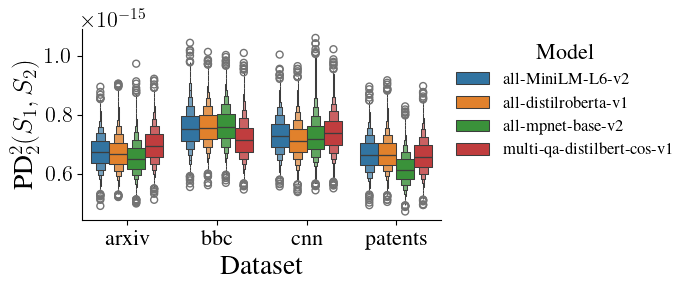

In [501]:
fig, ax = plt.subplots(1,1,figsize=(7,3), sharey=True)
sns.boxenplot(subsampled_df_agg, x="dataset", y="score", hue="model", ax=ax)
ax.legend(frameon=False, bbox_to_anchor=(1,1), title="Model", fontsize=legend_fontsize, title_fontsize=label_fontsize)
[l.set_fontsize(label_fontsize) for l in ax.get_xticklabels()]
[l.set_fontsize(label_fontsize) for l in ax.get_yticklabels()]
ax.yaxis.get_offset_text().set_fontsize(label_fontsize)
ax.set_ylabel(r"PD"+"$^2_2(S_1,S_2)$", fontsize=title_fontsize)
ax.set_xlabel("Dataset", fontsize=title_fontsize)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/subsampling_presto_boxen.pdf", bbox_inches="tight", transparent=True)